In [ ]:
import torch
import math
import torch.nn.functional as F

# 注意力模块
> 注意力 = 相似度打分 → Softmax 变权重 → 加权求和 <br>

三个变量: 查询值 Query，键值 Key 和 真值 Value

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

1. 计算缩放后的相似度分数 (Scores):

> scores是Query和每个key的相似度指数

$$\text{Scores} = \frac{Q \cdot K^T}{\sqrt{d_k}}$$

- $Q \in \mathbb{R}^{m \times d_k}$ :查询矩阵（Query），由 $m$ 个行向量垂直堆叠而成。
- $K^T \in \mathbb{R}^{d_k \times k}$: 键矩阵（Key）的转置。由于 $K$ 原本是按行垂直堆叠的，转置后每个词向量变为一列。
- $d_k$: 单头维度。即模型总维度被平分到每个头后的特征长度。  

   $Q$ 和 $K$ 的每一行向量长度正是 $d_k$（head_dim）


> attention score 标准维度表示为：$$(Batch\_Size,\ Num\_Heads,\ Seq\_Len,\ Seq\_Len)$$ 
> $$(B ,H  -头数,T  -query维度,T  -key维度)$$
>
>例如：$(2, 8, 5, 64)$ —— 2 句话，每句话 8 个头，每头 5 个词，每个词向量维度 64。
>
>矩阵乘法 $Q \times K^T$：
> - 在计算时，前两个维度 $(Batch, Num\_Heads)$ 保持不动。
> - 最后两个维度进行矩阵乘法：$(Seq\_Len, Head\_Dim) \times (Head\_Dim, Seq\_Len)$。
> - 结果：$(Seq\_Len, Seq\_Len)$。最终 scores 的维度：因此得到的 scores 维度就是 $(2, 8, 5, 5)$。<br>
其中:<br>
    > 2：代表模型同时在处理 2 个句子。<br>
    > 8：代表有 8 个不同的“专家”（Head）在从不同角度分析这些句子。<br>
    > 5 x 5：是这 8 个专家分别为这 2 个句子的词与词之间打的分数表。掩码（Mask）就是要盖在这个 5x5 的表上。

2. 计算注意力权重 (Attention Weights)
$$P_{attn} = \text{softmax}(\text{Scores})$$
此步骤通过 $\text{softmax}$ 将每一行的原始分数转化为和为 $1$ 的权重。

> **关于softmax作用** <br>
> 公式: 对于一个包含 $n$ 个元素的向量 $\mathbf{z}$（在注意力机制中，这就是某一个词对序列中所有词的得分），Softmax 函数的第 $i$ 个分量计算公式为：$$\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{n} e^{z_j}}$$ <br>
> 含义: 把一组“任意实数分数”，变成“一组和为 1 的概率/权重” <br>
> 作用: 用指数放大差异 + 用归一化变成权重分布


3. 计算最终输出 (Output)
$$\text{Output} = P_{attn} \cdot V$$
这是加权求和的过程，将权重矩阵与垂直堆叠的值矩阵 $V$ 相乘，提取出融合后的特征

矩阵乘法细节：对于每一个“头”里的每一个“查询词”：$$\text{Output}_i = \sum_{j=1}^{T} \text{Score}_{ij} \times \text{Value}_j$$其中 $j$ 是序列中所有的位置。如果 $\text{Score}_{i2} = 0.9$，则说明当前词 $i$ 的特征有 90% 取自第 2 个词的 Value

In [ ]:
""" 缩放点积注意力机制 Scaled Dot-Product Attention
"""

def attention(query, key, value, dropout=None):
    '''
    args:
    query: 查询值矩阵
    key: 键值矩阵
    value: 真值矩阵
    '''

    d_k = query.size(-1) # 键向量的维度(特征数)

    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)  # transpose——相当于转置
    
    p_attn = scores.softmax(dim=-1)

    if dropout is not None:
        p_attn = dropout(p_attn)
        
    return torch.matmul(p_attn, value), p_attn


In [ ]:
# 1. 初始赋值：定义词向量特征 (d_k = 2)
# 假设特征维度：[甜度, 硬度]
v_apple  = torch.tensor([1.0, 0.0])   # 苹果：甜，不硬
v_banana = torch.tensor([1.1, 0.1])   # 香蕉：也很甜，稍硬一点
v_chair  = torch.tensor([-0.8, 0.9])  # 椅子：不甜，很硬

# 2. 垂直堆叠形成 Key 矩阵 (K)
# 每一行代表一个词的特征
K = torch.stack([v_apple, v_banana, v_chair]) 
# K 的形状: [3, 2] (3个词, 每个词2个特征)

# 3. 定义 Value 矩阵 (V)
# 假设这是每个词对应的“营养价值”或“重要性得分”
V = torch.tensor([[10.0], [5.0], [2.0]]) 

# 4. 定义 Query (Q): 我们的意图是查找 "fruit"
# 假设 fruit 的向量特征也是 [1.0, 0.1]
Q = torch.tensor([[1.0, 0.1]])

# === 开始执行 attention 函数逻辑 ===

# 步骤 A: 获取维度并计算 Q K^T
d_k = Q.size(-1)
# transpose(-2, -1) 将 K 从 [3, 2] 转为 [2, 3] 以便矩阵相乘
scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

# 步骤 B: Softmax 得到注意力权重 (p_attn)
p_attn = F.softmax(scores, dim=-1)

# 步骤 C: 权重与 Value 相乘得到最终输出
context_vector = torch.matmul(p_attn, V)

# --- 打印结果验证 ---
print(f"Key 矩阵 (垂直堆叠):\n{K}")
print(f"注意力权重 (p_attn): {p_attn.tolist()}")
print(f"最终提取的值 (Value): {context_vector.item():.2f}")

Key 矩阵 (垂直堆叠):
tensor([[ 1.0000,  0.0000],
        [ 1.1000,  0.1000],
        [-0.8000,  0.9000]])
注意力权重 (p_attn): [[0.4202851355075836, 0.45428067445755005, 0.12543414533138275]]
最终提取的值 (Value): 6.73


## 掩码自注意力机制 Mask Self-Attention
使用注意力掩码的核心动机是让模型只能使用历史信息进行预测而不能看到未来信息  

transformer**训练**阶段: 利用已知label的优势, 通过数学手段在**并行矩阵**中强制执行“因果律”


公式:$$\text{Attention}(Q, K, V) = \text{Softmax}\left(\frac{QK^T}{\sqrt{d_k}} + \text{Mask}\right)V$$

假设输入序列长度是 $N$，掩码矩阵是一个 $N \times N$ 的方阵。在这个矩阵中： 
- 行（Row）：代表当前模型正在处理的词（Query）。
- 列（Column）：代表被观察/计算关联度的词（Key）。
- (逻辑掩码) Mask = 1 的位置：是指坐标 $(i, j)$ 中，$j > i$ 的所有位置。也就是说，对于第 $i$ 个词，所有在它之后的第 $j$ 个词都是“未来词”，这些位置在 Mask 矩阵里就被标记为 1。
- (数值掩码) 将 True 映射为 $-\infty$（如 -1e9）。将 False 映射为 $0$。


然后“注意力分数矩阵与掩码矩阵做和+softmax”激活:
- $e^{-\infty} = 0$，权重彻底归零
- $e^{\text{Score}}$ 正常计算，保留注意力。


In [ ]:
# --- 关键步骤 1：初始化预分配矩阵 ---
# 假设模型支持的最大长度为 1024
max_seq_len = 1024
# 创建一个全为 -inf 的矩阵
mask = torch.full((max_seq_len, max_seq_len), float("-inf"))

# --- 关键步骤 2：生成因果上三角结构 ---
# diagonal=1 表示保留主对角线以上的位置为 -inf
mask = torch.triu(mask, diagonal=1) 

    # 此时 mask 的形态（前4x4区域）：
    # [[  0., -inf, -inf, -inf],
    #  [  0.,   0., -inf, -inf],
    #  [  0.,   0.,   0., -inf],
    #  [  0.,   0.,   0.,   0.]]

# --- 关键步骤 3：根据当前序列长度动态切片并应用 ---
# 假设当前 batch 的实际序列长度 seqlen = 5
seqlen = 5
scores = torch.randn(2, 8, seqlen, seqlen)  # 模拟分数矩阵: (batch, num_heads, seqlen, seqlen)

# 利用广播机制进行求和遮蔽
# mask[None, None, :seqlen, :seqlen] 将维度扩展为 (1, 1, seqlen, seqlen)
masked_scores = scores + mask[:seqlen, :seqlen]

# --- 关键步骤 4：Softmax 归一化 ---
# 确保在 float32 下计算以维持数值稳定性
import torch.nn.functional as F
probs = F.softmax(masked_scores.float(), dim=-1)

## 多头注意力机制 Multi-Head Attention

模型不会只用一种方式去理解句子，而是并行地运行多个“头”。  
`attention head` 是并行的特征提取器。  
每个`head` 关注不同的语义关系。比如，一个头可能负责寻找主谓关系，另一个头负责寻找代词指代

n个“头”（Head）都拥有一套独立的参数矩阵 $W_Q^i, W_K^i, W_V^i$  
根据不同参数矩阵通过反向传播实现不同注意力结果, head1 可能会学着去关注动词和名词的关系，而 head2 可能会学着去关注句子中的代词指代。  
结果：这种设计让模型能够同时在 $n$ 个不同的表示空间（Representation Subspaces）中捕捉信息，而不是只在一个空间里“平均化”所有的联系。

> 并行多头计算: 使用三个组合矩阵来代替了n个参数矩阵的组合, 其逻辑在于矩阵内积再拼接其实等同于拼接矩阵再内积

公式:
$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h)W^O$$
- 输入端：拼接后的向量维度为 $B \times T \times (h \cdot d_k)$（即 $B \times T \times \text{dim}$）。
- 矩阵维度：$W_O \in \mathbb{R}^{\text{dim} \times \text{dim}}$（或 $\mathbb{R}^{(h \cdot d_k) \times \text{dim}}$）。
- 输出端：映射回原始的模型隐藏层维度 $B \times T \times \text{dim}$

**为什么必须要有 $W_O$？（物理意义）**  
如果不使用输出投影矩阵，多头注意力机制就会存在以下缺陷：  
- 缺乏交互：各个头（Heads）是在不同的子空间独立运行的，拼接后的结果仅仅是信息的堆叠，不同头之间没有发生化学反应。  
- 维度锁定：拼接后的特征分布可能不符合后续残差连接或前馈网络的要求。  
- 整合信息：$W_O$ 是多头注意力真正实现“信息整合”的地方。它通过线性变换，学习如何加权组合不同专家的意见，从而在原始的维度空间中形成更强大的特征表达。

1. 投影  
输入--隐藏张量信息 hidden states: 
$$X \in \mathbb{R}^{B \times T \times dim}$$
B：batch size . 模型一次处理多少个句子  
T：序列长度 . 每个句子包含多少个 token     
dim：模型维度（embedding / hidden size）  
$X$ 是由初始的词嵌入（Embedding）经过一层或多层 Transformer Block 处理后生成的中间特征表示 

PS: 
为什么叫“隐藏”状态:
- 输入层是可见的（Token ID）
- 输出层是可见的（概率分布）  
- 中间层（Transformer 各个层）产生的特征表示并不直接对应人类能直观读懂的字符，它们在黑盒内部流动，因此被称为“隐藏状态” 

同一个输入向量 X 先通过三个相互独立、可学习的线性投影 $W_q, W_k, W_v$ ，映射到 Query,key,Value 三种不同的表示空间  
其中，Query 和 Key 负责建模 token 之间的匹配关系（关注谁），Value 负责承载被聚合的语义内容（传递什么信息）   
这种设计实现了 “匹配机制”与“信息内容”的解耦，显著提升了模型的表达能力与灵活性

| 投影    | 全称    | 所属表示空间含义        | 核心作用     | 决定的问题          | 直觉理解                |
| ----- | ----- | --------------- | -------- | -------------- | ------------------- |
| **Q** | Query | **查询空间 / 需求空间** | 发起注意力    | *我想关注谁？*       | 当前 token 在“找什么信息”   |
| **K** | Key   | **键空间 / 索引空间**  | 被匹配的特征   | *我能被谁关注？*      | 这个 token 在哪些维度上“显眼” |
| **V** | Value | **值空间 / 内容空间**  | 被加权汇聚的信息 | *如果被选中，我输出什么？* | 真正被传递的语义内容          |


(1)单个 Token 的线性投影逻辑  
对于输入序列中的任意一个 Token 向量 $x \in \mathbb{R}^{1 \times n_{\text{embd}}}$，我们通过三个权重矩阵将其转换为三个不同的功能角色：$$Q = x W_Q, \quad K = x W_K, \quad V = x W_V$$

维度匹配：  
- $x$ 的维度为 $(1, n_{\text{embd}})$。  
- $W_Q, W_K, W_V$ 的维度均为 $(n_{\text{embd}}, \text{dim})$。  
- 结果：生成的 $Q, K, V$ 维度均为 $(1, \text{dim})$。

物理意义：这一步实现了将“原始特征”投影到“注意力空间”。$W_Q$ 学习如何发起提问，$W_K$ 学习如何被索引，$W_V$ 提取核心语义信息。  


(2) 分块矩阵与多头拼接的等价性  
`self.wq = nn.Linear(n_embd, dim)` 实际上是 $h$ 个小矩阵在**列方向**上的拼接：  

$$
W_Q =
\begin{bmatrix}
W_Q^{(1)} | W_Q^{(2)} | \cdots & W_Q^{(h)}
\end{bmatrix}
$$

子空间性质：每个头 $W_Q^{(i)}$ 的维度是 $(n_{\text{embd}}, \text{head\_dim})$。  
计算一致性：  
- 逻辑上：我们本应计算 $h$ 次独立的矩阵乘法：$q^{(i)} = x W_Q^{(i)}$。  
- 工程上：我们只计算一次大矩阵乘法 $x W_Q$，得到的结果向量 $[q^{(1)}, q^{(2)}, \dots, q^{(h)}]$ 长度为 $\text{dim}$。  
- 结论：单次大矩阵运算的结果，在数值上完全等同于先分别计算各头结果再进行拼接（Concatenation）

> 分块矩阵核心在于计算的等价性:
一个向量 $x$ 与该分块矩阵相乘的结果，等于 $x$ 分别与每个子块相乘后再进行拼接：$$x \cdot W_Q = [x \cdot W_Q^{(1)}, x \cdot W_Q^{(2)}, \dots, x \cdot W_Q^{(h)}]$$
> - 左侧：是代码中实际执行的一次大矩阵内积。
> - 右侧：是逻辑上的 $n$ 个参数矩阵分别内积后再拼接。
> - 结论：矩阵内积再拼接等同于拼接矩阵再内积。这正是利用了分块矩阵的线性性质。

(3) 投影的输入和输出端:  
    `args.n_embd` (投影矩阵的输入端) : 代表进入注意力层之前的特征向量长度。通常由 Embedding 层直接输出  
    `args.dim`(投影矩阵的输出端) : 决定了经过线性变换后，信息被投影到了一个多大的空间中   
    公式化理解：如果我们将注意力层看作一个函数 $f$，那么：$$X_{out} = f(X_{in}W) + X_{in}$$其中，$X_{in}$ 的宽度是 输入特征维度，而矩阵 $W$ 投影后的宽度是 模型隐藏层维度
  
   
在标准 Transformer 实现中，我们经常看到 n_embd == dim。这种设计主要是为了支持 残差连接 (Residual Connection)：   
- 维度一致性：残差连接要求 $Output = Layer(Input) + Input$。为了让相加操作成立，Layer 的输出维度（隐藏层维度）必须与输入维度（特征维度）完全匹配。  
- 信息流动：如果两者不等，就必须引入额外的投影矩阵来强行对齐维度，这会增加模型的参数量和计算开销。

2. dropout层  

Dropout 层是一种极其重要且常用的正则化（Regularization）技术。它的核心目的是通过在训练过程中随机“关闭”一部分神经元，来防止模型产生过拟合（Overfitting）  

核心工作原理：随机丢弃  
在模型训练的每一次迭代（Iteration）中，Dropout 层会按照预设的概率 $p$（即 dropout_rate）随机将一部分神经元的输出值置为 0。  
- 训练阶段：神经元以概率 $p$ 被“杀死”，这意味着网络在每次前进时都在使用一个不同的、缩小的“子网络”进行学习。  
- 测试/推理阶段：Dropout 会被关闭，所有神经元都保持激活状态。为了补偿训练时的丢失，通常会对输出进行缩放（Scaled Dropout），以保证训练和预测时的数值量级一致。

| 名称              |一句话| 对象|核心职能                      | 作用位置                       | 属于哪一阶段 | 数学形式                                                                 |
| --------------- |----|--|------------------------- | -------------------------- | ------ | -------------------------------------------------------------------- |
| `attn_dropout`  |正则化“我看谁”|token-token的连接| 保护权重分布，防止注意力机制出现“过热”或单一依赖 | 注意力权重矩阵（Attention Weights） | 注意力内部, 防止注意力塌缩  | $\tilde{A} = \text{Dropout}(\text{Softmax}(QK^\top / \sqrt{d_k})) $|
| `resid_dropout` |正则化“我学到了什么”| 新生成的特征信息| 整体特征正则化，配合残差连接提升深度网络的泛化性  | 子层输出（Attention / FFN 输出）   | 残差连接前, 防止子层过拟合  | $ x_{l+1} = x_l + \text{Dropout}(\text{SubLayer}(x_l)) $             |


> **模型的缓冲区（buffer）机制**  : 不是参数、不会被训练更新，但会被模型“记住”、随模型一起移动和保存的张量

| 类型            | 是否参与训练 | 是否保存 | 是否随 `.to(device)` 移动 | 典型例子                        |
| ------------- | ------ | ---- | -------------------- | --------------------------- |
| **Parameter** | ✅ 是    | ✅ 是  | ✅ 是                  | 权重、偏置                       |
| **Buffer**    | ❌ 否    | ✅ 是  | ✅ 是                  | attention mask、running mean |
| 普通 Tensor     | ❌ 否    | ❌ 否  | ❌ 否                  | 中间变量                        |

> 关于`is_causal`

任务分成:  
- 生成式: “下个词是什么” -- 不能看未来 (is_causal = true)
- 理解式: “这个词整体是什么意思” -- 可以上下文 (is_causal = false)

**拆头公式：**  
Input (B, T, C) $\xrightarrow{Linear}$ (B, T, H*d_k) $\xrightarrow{view}$ (B, T, H, d_k) $\xrightarrow{transpose}$ (B, H, T, d_k)  

一句话总结：view 负责在特征空间上把向量切开，transpose 负责在内存布局上把头挪到前面，以便实现硬件级别的并行计算。

标准transfomer中:   $dim == n_{embd}$

但是这只是个设计选择,不是数学必然,如以下情况:
- 多查询 / 多键注意力（MQA / GQA）
- 投影瓶颈 Attention（Attention Bottleneck）
- 跨模态 Attention（Cross-
- MoE / Adapter / Low-Rank Attention

> C 是什么  

在 Transformer 的语境下，$C$ 通常代表 Channel（通道）或 Dimension（维度）。它是模型中最重要的超参数之一。  

1. $C$ 的物理意义：特征的“宽度”如果把输入序列比作一篇文章：$T$ (Sequence Length)：代表文章里有多少个词（Token）。$C$ (Channel/Dimension)：代表每一个词被多少个数字（特征）来描述。$C$ 越大，模型对单个词的“刻画”就越细腻。 例如，在 $C=512$ 的模型中，每个词都有 512 个维度的数值来表达它的语义、语法、情感等信息。   

2. $C$ 在不同阶段的称呼虽然数值一样，但在不同层级，大家对 $C$ 的叫法略有不同：   

|阶段|常用符号|名称|含义|
|--|----|----|----|
|最开始|n_embd|Embedding Dimension|词表里的原始向量长度|
|层之间|dim / dmodel|Model Dimension|在 Transformer Block 之间流转的特征宽度|
|FFN 内部|hidden_dim|Hidden Dimension|FNN 升维后的宽度（通常是 4C）|
|Attention|dk​|Head Dimension|每个注意力头的宽度（C 除以头数）| 

3. $C$ 是模型“思考”的带宽。带宽越宽（$C$ 越大），模型能同时处理和记忆的特征细节就越多，但计算成本（显存占用）也会随之平方级增长。

In [ ]:
import torch.nn as nn
from dataclasses import dataclass

""" 数据类装饰器
    根据“类属性的类型注解”，自动生成构造函数等方法
"""
@dataclass
class ModelArgs: 
    dim: int          # 模型的隐藏层维度 (投影矩阵的输出端维度) 
    n_heads: int      # 头数    
    head_dim: int     # 每个head独立处理的子空间维度 (= d_k)
    n_embd: int       # 输入特征维度(投影矩阵的输入端维度)   [每一个token被embedding后用一个多少维的向量表示]
    max_seq_len: int  # 模型支持的最大序列长度
    dropout: float    # dropout 概率


class MultiHeadAttention(nn.Module):
    def __init__(self, args:ModelArgs,is_causal:bool=False):
        """multi-head attention机制的初始化

        Args:
            args (ModelArgs): 模型参数
            is_causal (bool, optional): 是否使用因果遮蔽. Defaults to False.
        """
        # === 1. 维度检查 ===
        super().__init__()
        # 约束条件:总维度dim可以被头数n_heads整除,每个头的特征量head_dim完全相等(数学公式中的 d_k)
        assert args.dim % args.n_heads == 0
        self.head_dim = args.dim // args.n_heads
        self.n_heads = args.n_heads
        
        # === 2. 投影矩阵参数 ===
        # Wq, Wk, Wv 参数矩阵，每个参数矩阵为 n_embd x dim
        self.Wq = nn.Linear(args.n_embd, self.n_heads * self.head_dim, bias=False)
        self.Wk = nn.Linear(args.n_embd, self.n_heads * self.head_dim, bias=False)
        self.Wv = nn.Linear(args.n_embd, self.n_heads * self.head_dim, bias=False)
        # Wo 输出权重矩阵: 维度为 (dim , dim) 的线性层. 将不同 head 加权融合
        self.Wo = nn.Linear(self.n_heads * self.head_dim, args.dim, bias=False)
        
        # === 3.  dropout层 === 
        self.attn_dropout = nn.Dropout(args.dropout)
        self.resid_dropout = nn.Dropout(args.dropout)
        
        # === 4. 注意力遮蔽 === 
        self.is_causal = is_causal
        if is_causal: 
            #  mask维度是 (1,1,T,T)  ,scores维度是 (B,H,T,T)
            mask = torch.full((1, 1, args.max_seq_len, args.max_seq_len), float("-inf"))
            mask = torch.triu(mask, diagonal=1)
            # 注册为模型的缓冲区
            self.register_buffer("mask", mask) 
            
    def forward(self, q: torch.Tensor, k: torch.Tensor, v: torch.Tensor):
        """Multi-Head Scaled Dot-Product Attention

        Args:
            q,k,v (torch.Tensor):输入张量,形状为 (B, T, n_embd)
                B: batch size
                T: 序列长度 (时间步)
                n_embd: 输入特征维度(投影矩阵的输入端维度)   [每一个token被embedding后用一个多少维的向量表示]

        Returns:
            output: 注意力输出，形状为 (B, T, n_embd)
        """
        # === 0. 获取输入维度 ===
        batch_size, seq_len, _ = q.shape  # 在进入attention前，q维度为 (B, T, n_embd)
        
        
        # === 1. 线性投影 ===
        # 输入通过参数矩阵层，映射到 Q,K,V 空间
        # 维度变化: (B, T, n_embed) x (n_embed, dim) -> (B, T, dim)
        Q = self.Wq(q)  
        K = self.Wk(k)  
        V = self.Wv(v)  
        
        # === 2. 拆分多头 ===
        # 将长向量切分为多个头的子空间表示
        # (B, T, dim) -> (B, T, n_heads, head_dim)
        Q = Q.view(batch_size, seq_len, self.n_heads, self.head_dim)
        K = K.view(batch_size, seq_len, self.n_heads, self.head_dim)
        V = V.view(batch_size, seq_len, self.n_heads, self.head_dim)
        # 提前 `头维度` , 以便进行 Batch 级别的并行矩阵运算
        # (B, T, n_heads, head_dim) -> (B, n_heads, T, head_dim)
        Q = Q.transpose(1, 2)
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)
        
        # === 3. Scaled Dot-Product Attention ===
        # 计算 QK^T / sqrt(d_k),得到 scores_{ij}: 表示第 i 个token 对第 j 个 token的注意力得分
        # (B, n_heads, T, head_dim) x (B, n_heads, head_dim, T) -> (B, n_heads, T, T)
        # 每一个(T,T)矩阵表示序列内词语词之间的两两相关性
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        
        # 应用因果遮蔽
        if self.is_causal:
            assert hasattr(self, 'mask')
            scores = scores + self.mask[:, :, :seq_len, :seq_len]  # 动态截取 + 广播机制
            
            # 对 key 维做 softmax 归一化: 对所有 query 位置，计算其对应所有 key 位置的权重分布
            # 维度含义 [B, n_heads,T (Query_index) , T (Key_index)]
            scores = F.softmax(scores.float(), dim=-1).type_as(Q)
            scores = self.attn_dropout(scores)
            
            # 加权求和得到每个head输出
            # (B, n_heads, T, T) × (B, n_heads, T, head_dim)
            # -> [B, n_heads, T, head_dim]  banch, head, token时间步,该head的子空间表示
            output = torch.matmul(scores, V) 
            
        # === 4. 合并多头 concatenate heads ===
        #恢复维度：将并行的头重新排列回序列维度
        # (B, n_heads, T, head_dim) -> (B, T, n_heads, head_dim)
        # 矩阵转置目的是按照时间步 token 拼接所有head的输出, token t 表示 = [head1(t|), head2(t|),..., headn(t|)]
        output = output.transpose(1, 2).contiguous()  
        
        
        # concate 最后两维度,拼接所有 head 的子空间表示
        # (B, T, n_heads, head_dim) -> (B, T, dim)
        output = output.view(batch_size, seq_len, -1)
        
        
        # === 5. 输出投影 + Dropout（Residual Stream） ===
        # (B, T, dim) → (B, T, n_embd)
        output = self.Wo(output) # 交互不同 head 的信息
        output = self.resid_dropout(output) #预防过拟合:在送回残差连接前做dropout
        return output

## 分组查询注意力机制 Groped-Query Attention, GQA
是一种介于标准多头注意力（MHA）和多查询注意力（MQA）之间的折中方案，目前在 LLaMA、Qwen、Mistral 等大模型中被大量采用

 为什么需要 GQA？（从 MHA → MQA → GQA） 

|特征|MHA (多头注意力)|MQA (多查询注意力)|GQA (分组查询注意力)| 
|--|-----|-------|---------|
|结构|每个 Query (Q) 都有独立的 Key (K) 和 Value (V)|所有 Q 共享同一组 K 和 V|多个 Q 组成一组，共享一组 K 和 V| 
|KV Cache 占用|极高（随 Head 数量线性增长）|极低|中等（可根据分组数量调节）| 
|模型性能|最优|较差（信息压缩严重，容易丢失细节）|接近 MHA| 
|推理速度|较慢|最快|极快（显著优于 MHA）| 

<div align='center'>
    <img src="https://raw.githubusercontent.com/datawhalechina/happy-llm/main/docs/images/5-images/llama2-attention.png" alt="alt text" width="50%">
    <p>图  LLaMA2 Attention 结构</p>
</div>

> `repeat_kv函数`   

在 GQA 架构中，查询（Query）头数`n_heads`通常多于键（Key）/值（Value）头数`n_kv_heads`。为了能够进行矩阵乘法，我们需将 Key 和 Value 在 head 维度上扩展，使其头数与 Query 对齐。  
1. 确定重复倍数：计算 $n_{\text{rep}} = \frac{n_{\text{heads}}}{n_{\text{kv\_heads}}}$  
2. 插入扩展维度：将原始 KV 张量形状从 (批量大小、序列长度、键/值对头的数量、每个头的维度大小) 通过 x[:, :, :, None, :] 变为 (批量大小、序列长度、键/值对头的数量、1、每个头的维度大小)   
3. 视图广播：使用 .expand 将中间的 1 维度扩展为 n_rep，此时逻辑形状为(批量大小、序列长度、键/值对头的数量、n_rep、每个头的维度大小)   
4. 物理合并：合并键/值对头的数量和重复次数的维度，得到（B，T，n_heads，head_dim）

> 旋转嵌入 Rotary Positional Embedding, RoPE  

参考：  
https://www.youtube.com/watch?v=o29P0Kpobz0    
https://www.youtube.com/watch?v=V8r__fXx7tU  

核心思想：在 Query 和 Key 空间中引入位置相关的旋转变换，将高维空间中的embeddding通过“旋转”的方式注入相对位置信息，进入将位置信息隐式地融入注意力计算过程，在不增加额外参数的情况下显著提升了模型对长序列的建模能力

[note]: 值向量 $V$ 承载的是纯粹的语义特征。一旦通过 $Q$ 和 $K$ 计算出了“谁该看谁”，模型只需要从 $V$ 中提取对应位置的特征进行加权求和即可，不需要再对 $V$ 进行旋转处理。

2D 旋转矩阵：为了计算效率，RoPE 并不直接旋转整个高维向量，而是将其拆分成多个二维子向量，并在每个二维平面上应用旋转矩阵

在 RoPE 中，每一组**二维**特征向量被视为一个**复数**。对于位置为 $m$ 的词，其特征向量会旋转一个角度 $m\theta$： 
- 绝对位置旋转：每个位置的词向量旋转的角度与其索引 $m$ 成正比。  
- 相对位置内积：当两个向量（位置 $m$ 的 Query 和位置 $n$ 的 Key）进行点积时，结果只取决于它们之间的旋转角度差 $(m-n)\theta$。



数学实现与关键参数：  
1. 计算位置频率：RoPE 使用公式来确定每个维度对的旋转频率，这涉及到参数 $k$(维度对的索引) 、 $\theta$。 
$$
\omega_k = \theta^{-2k/d}
$$



2. 参数 $\theta$ 的作用：$\theta$ 的默认值通常为 10,000。  
- 较小的 $\theta$：旋转速度快，适合短上下文，帮助模型区分精细的位置差异。  
- 较大的 $\theta$：旋转速度慢，适合处理超长上下文（如 100,000 个 Token），防止旋转周期过快导致的位置重叠。  
3. 复数形式：在代码实现中，旋转通常通过复数乘法（实部和虚部）来高效完成

计算流程： 
1. 预计算频率矩阵   
2. 准备特征对
3. 执行旋转变换

# 序列建模架构
## Seq2Seq
Seq2Seq,即序列到序列  
一般的思路是对自然语言序列进行编码再解码。所谓编码，就是将输入的自然语言序列通过隐藏层编码成能够表征语义的向量（或矩阵），可以简单理解为更复杂的词向量表示。而解码，就是对输入的自然语言序列编码得到的向量或矩阵通过隐藏层输出，再解码成对应的自然语言目标序列

<div align="center">
  <img src="https://raw.githubusercontent.com/datawhalechina/happy-llm/main/docs/images/2-figures/2-0.jpg" alt="图片描述" width="90%"/>
  <p>图2.5 编码器-解码器结构</p>
</div>

Transformer 由 Encoder 和 Decoder 组成，每一个 Encoder（Decoder）又由 6个 Encoder（Decoder）Layer 组成。输入源序列会进入 Encoder 进行编码，到 Encoder Layer 的最顶层再将编码结果输出给 Decoder Layer 的每一层，通过 Decoder 解码后就可以得到输出目标序列了。

一个 Transformer Encoder Layer 只有两件事：

1. 多头自注意力（MHSA）

2. 前馈神经网络（FFN）

每个子层外面都包着两样东西：

- 残差连接（Residual）

- LayerNorm（LN）

👉 Pre-LN 和 Post-LN 的区别，只在 LayerNorm 放在哪

## Transformer Block

### 前馈神经网络 Feed Forward Neural Network, FNN

> 每一个 Encoder Layer 都包含**一个注意力机制**和**一个前馈神经网络**    

Transformer 的前馈神经网络是由两个线性层中间加一个 RELU 激活函数组成的，以及前馈神经网络还加入了一个 Dropout 层来防止过拟合

> Decoder 由**两个注意力层**和**一个前馈神经网络**组成。    

第一个注意力层是一个掩码自注意力层，即使用 Mask 的注意力计算，保证每一个 token 只能使用该 token 之前的注意力分数  
第二个注意力层是一个多头注意力层，该层将使用第一个注意力层的输出作为 query，使用 Encoder 的输出作为 key 和 value，来计算注意力分数

|阶段|算子操作|维度变换 (Tensor Shape)|核心功能 (Logical Purpose)|备注|
|----|---|----|-----------|---|
|1. 输入|Residual Input|(B,T,C)|接收 Attention 层输出并 LayerNorm 后的特征。|初始语义状态|
|2. 升维|Linear(C, 4C)|(B,T,C)→(B,T,4C)|空间扩张：投影到更高维空间以捕捉复杂模式。|参数量最大的步骤|
|3. 激活|ReLU / GeLU|(B,T,4C)→(B,T,4C)|非线性变换：引入非线性，筛选并保留关键信号。|增加模型表达深度|
|4. 降维|Linear(4C, C)|(B,T,4C)→(B,T,C)|特征压缩：提取精华并回归主维度，准备残差连接。|信息提纯|
|5. 正则|Dropout|(B,T,C)→(B,T,C)|防止过拟合：增强模型泛化能力。|训练时开启|
|6. 输出|Residual Add|(B,T,C)|将 FFN 结果加回输入，形成残差流。|X+FFN(X)|


FNN核心公式:  
$$FFN(x) = \text{Dropout}(\text{Linear}_2(\text{Activation}(\text{Linear}_1(x))))$$

`Attention` 是token间的建模  
`FFN` 是单个token的特征变换与增强

In [ ]:
""" 逐位置前馈神经网络 Position-wise FFN:

    通过“线性升维 → 非线性激活 → 线性降维”的结构增强特征表示能力，
    并通过 Dropout 提高模型的泛化性能
"""
class FeedForward(nn.Module):
    def __init__(self, dim: int, hidden_dim: int, dropout: float):
        """
        Args:
            dim (int): 输入 / 输出维度（= 模型隐藏维度 n_embd ）
            hidden_dim (int): FFN 中间层维度（通常 = 4 × dim ）
            dropout (float): 随机失活比例 
        """
        super().__init__()
        
        self.w1 = nn.Linear(dim, hidden_dim, bias=False) # 第一层: 升维
        self.w2 = nn.Linear(hidden_dim, dim, bias=False) # 第二层: 降维
        self.dropout = nn.Dropout(dropout) # dropout层
        
        def forward(self, x):
            # 首先，输入x通过第一层线性变换和RELU激活函数
            # 最后，通过第二层线性变换和dropout层
            return self.dropout(self.w2(F.relu(self.w1(x))))
    

### 层归一化 Layer Norm  
归一化的本质是解决 内部协变量偏移 (Internal Covariate Shift) 问题，通过稳定每一层输入的分布，加速模型收敛并提升泛化能力。  

神经网络主流的归一化一般有两种，批归一化（Batch Norm）和层归一化（Layer Norm）

- Batch Norm 相当于在“纵向”对不同样本的同类特征进行规范化，适合空间结构明显的图像数据。

- Layer Norm 相当于在“横向”对同一个样本的多种特征进行规范化，适合时间/序列逻辑明显的文本数据。

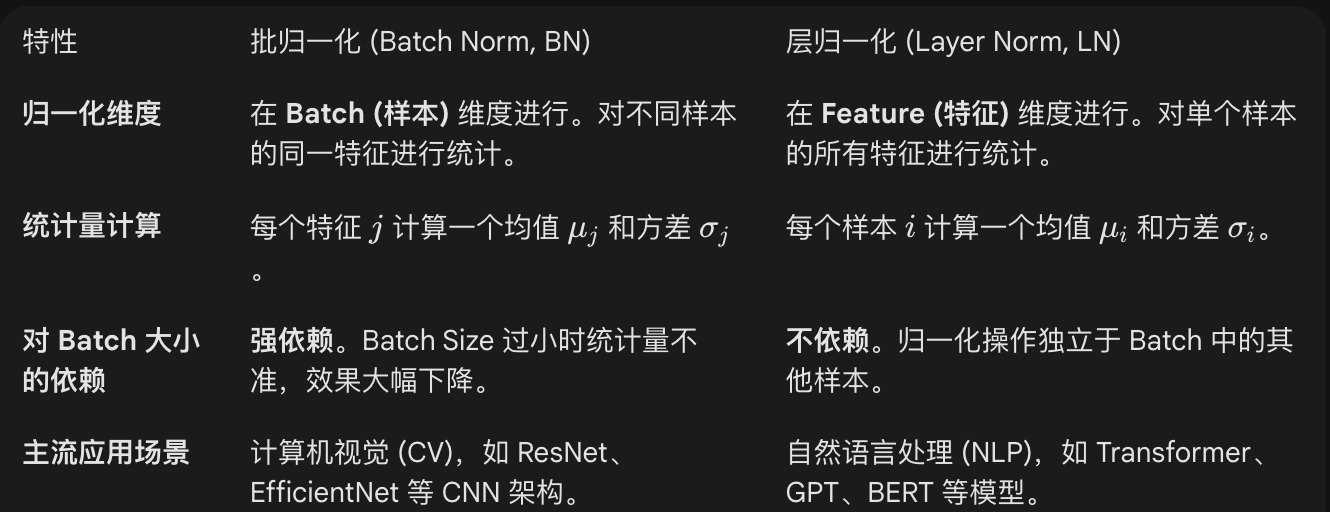

假设我们的张量维度是 $(B, T, C)$，即（批次，序列长度，特征维度）。  

 批归一化 (Batch Norm): 跨样本切片  
 - 计算范畴：固定特征 $j$ 和位置 $t$，在 Batch 维度 $B$ 上求 $\mu$ 和 $\sigma$。
 - 数学直觉：$\mu_{j,t} = \frac{1}{B} \sum_{i=1}^{B} Z_{i,t,j}$。
 - 通俗理解：BN 试图让“这一批句子”里，处于同一个位置的词的同一个特征，都服从某种分布。  
 
 层归一化 (Layer Norm): 样本内切片
 - 计算范畴：固定样本 $i$ 和位置 $t$，在特征维度 $C$ 上求 $\mu$ 和 $\sigma$。
 - 数学直觉：$\mu_{i,t} = \frac{1}{C} \sum_{j=1}^{C} Z_{i,t,j}$。
 - 通俗理解：LN 试图让“这一个单词”内部的所有特征（Channel），都服从某种分布。

两者的数学形式完全一致，区别仅在于 $\mu$ 和 $\sigma$ 的计算范畴：$$\hat{Z} = \frac{Z - \mu}{\sqrt{\sigma^2 + \epsilon}}$$
在实际实现中，通常还会引入两个可学习的参数 $\gamma$ (weight 缩放) 和 $\beta$ (bias 平移)，以保留模型的表达能力：$$\text{Output} = \gamma \cdot \hat{Z} + \beta$$

BN 像是班级评分：根据全班同学（Batch）的平均分来调整你的得分。  
 LN 像是个人测评：根据你身上所有学科（Features）的平均分来调整你这一科的深度。

In [ ]:
class LayerNorm(nn.Module):
    ''' Layer Norm 层'''
    def __init__(self, features, eps=1e-6):
        super().__init__()
        
        self.gamma = nn.Parameter(torch.ones(features)) # 缩放参数
        self.beta = nn.Parameter(torch.zeros(features)) # 平移参数
        self.eps = eps # 防止除零错误

    def forward(self, x): # x:[B,T,C]
        # 指定在最后一个维度(C)上计算
        mean = x.mean(-1, keepdim=True) # mean: [B, T, 1]
        std = x.std(-1, keepdim=True) # std: [B, T, 1]
        return self.gamma * (x - mean) / (std + self.eps) + self.beta

#### RMSNorm

RMSNorm（Root Mean Square Normalization）是一种不减均值、只做尺度归一化的归一化方法

`RMSNorm`可以用如下的数学公式表示：

$$
\text{RMSNorm}(x) = \frac{x}{\sqrt{\frac{1}{n}\sum_{i=1}^{n}x_i^2 + \epsilon}} \cdot \gamma
$$

其中：
- $x_i$ 是输入向量的第 $i$ 个元素
- $\gamma$ 是可学习的缩放参数（对应代码中的 `self.weight`）
- $n$ 是输入向量的维度数量
- $\epsilon$ 是一个小常数，用于数值稳定性（以避免除以零的情况）

| 方法        | 减均值 | 除方差    | 可学习参数 |
| --------- | --- | ------ | ----- |
| LayerNorm | ✅   | ✅      | γ + β |
| RMSNorm   | ❌   | ✅（RMS） | γ     |



RMSNorm相比LayerNorm:  
- 计算效率更高： LayerNorm 需要计算均值和方差，这意味着要对数据进行两遍扫描（先求和算均值，再求平方和算方差）。而 RMSNorm 只需要计算平方和，减少了计算开销. 
- 均值偏移不重要: 神经元输出的均值漂移对模型性能影响不大，真正起作用的是通过“缩放”（除以标准差/均方根）来稳定梯度的量级

### 残差连接 
残差连接，即下一层的输入不仅是上一层的输出，还包括上一层的输入。残差连接允许最底层信息直接传到最高层，让高层专注于残差的学习。

>post-Layer Normalization （原始 Transformer，2017）  

在进行残差连接计算时，先完成残差计算（即 $x + SubLayer(x)$），再对结果进行 LayerNorm 计算 

公式表达：$x_{out} = LayerNorm(x + SubLayer(x))$


>Pre-Layer Normalization（现代 Transformer / GPT / LLaMA） 

先对输入进行 LayerNorm 计算，再进入注意力层或 MLP 层计算，最后进行残差相加

公式表达：$x_{out} = x + SubLayer(LayerNorm(x))$

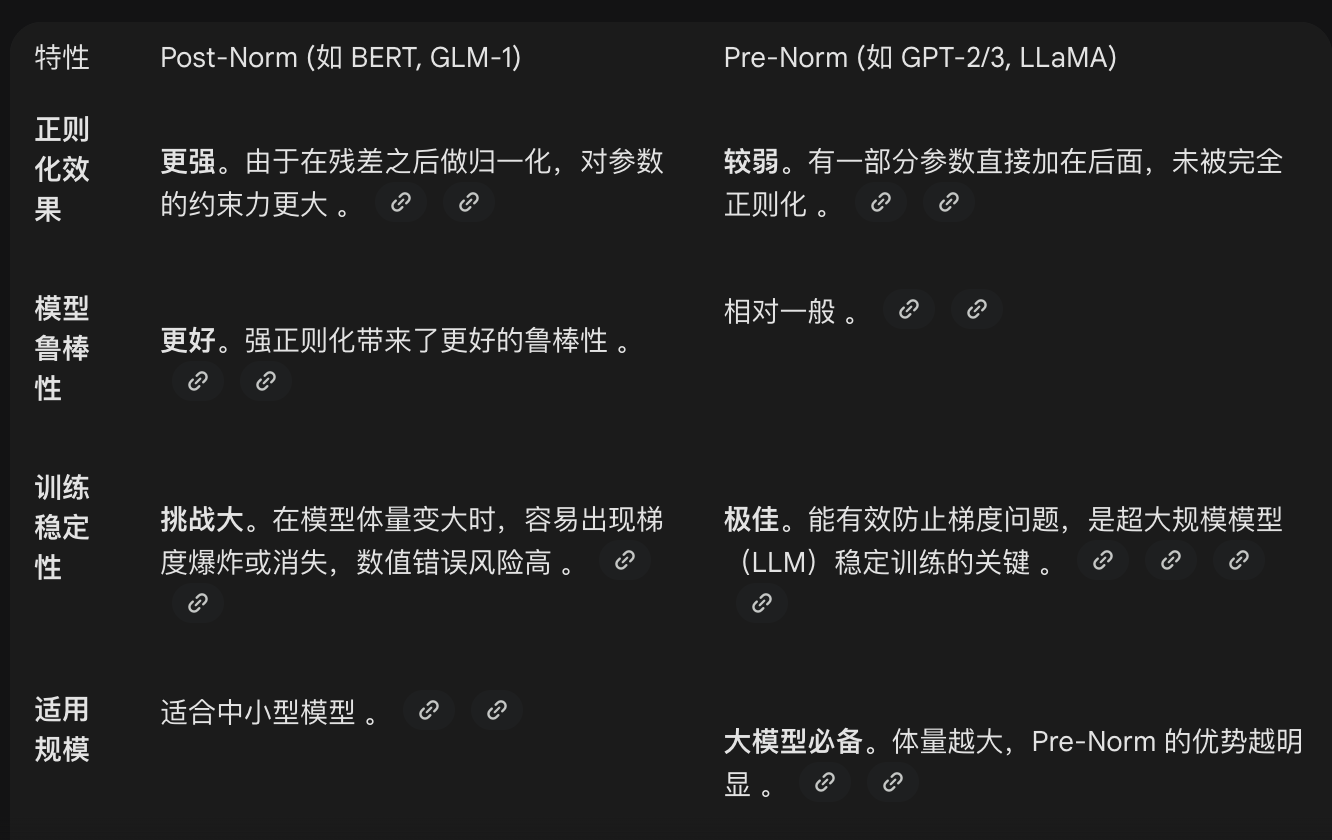

# 完整 Transformer 模型

## transformer bolck的应用场景: Encoder & decoder
Transformer Block 的本质： 它是一个**特征重写器**。每一层 Block 都会基于上一层的表达，通过“对话”（Attention）和“思考”（FFN），输出更高级、更抽象的语义向量 

根据应用场景的不同（Encoder 或 Decoder），Block 的内部组成略有差异。

1. 核心计算组件 (The Core Processors)这是 Block 中负责处理信息和特征提取的部分：  
- 多头自注意力层 (Multi-Head Self-Attention, MSA)：  
    作用：建立词与词之间的联系。让模型能够根据上下文理解当前词的含义。  
    区别：在 Decoder Block 中，这一层通常是“掩码”（Masked）的，以防止模型在生成时看到未来的词。
- 前馈神经网络 (Feed-Forward Network, FFN)：  
    作用：对每个位置的特征进行非线性变换和增强。它通常由两个线性层（Linear）中间夹一个激活函数（ReLU 或 GeLU）组成。  
- 交叉注意力层 (Cross-Attention) —— 仅限 Decoder： 
    作用：这是 Decoder 独有的。它让解码器能够关注到编码器（Encoder）输出的特征信息，实现“看原句，出译文”。  
    
2. 基础设施组件 (The Infrastructure)这些组件不直接处理语义，但确保了深层网络能够训练成功：  
- 层归一化 (Layer Normalization, LN)：  
    作用：稳定数值分布，防止梯度爆炸或消失。  
    位置：分为 Pre-LN（在计算层之前）和 Post-LN（在计算层之后）。 
- 残差连接 (Residual Connection)：  
    作用：通过 $x + SubLayer(x)$ 的方式，允许原始信号绕过复杂运算直接向后传递，缓解深层网络的退化问题。  
- Dropout 层：  
    作用：正则化技术，在训练过程中随机关闭部分神经元，防止过拟合。  

### encoder 层级结构

Encoder (编码器总成)  
│
├── 0. Input Stage (输入准备)  
│   ├── Token Embedding 
│   └── Positional Encoding 
│
├── 1. Encoder Layer × N (堆叠的加工单元)  
│   │  
│   ├── [子层 1: 自注意力]  
│   │   ├── LayerNorm (归一化: 稳定输入分布) ──┐  
│   │   ├── Multi-Head Self-Attention (核心: 词间交互) │ (残差连接路)  
│   │   └── Residual Connection (x + SubLayer) <───┘  
│   │  
│   └── [子层 2: 前馈特征加工]  
│       ├── LayerNorm (归一化: 稳定注意力后的分布) ─┐  
│       ├── Feed Forward Network (MLP: 深度非线性变换)│ (残差连接路)  
│       └── Residual Connection (h + SubLayer) <────┘  
│
└── 2. Final Output (输出)    
    └── Final LayerNorm    

### decoder层级结构

Decoder (解码器总成)   
│
├── 0. Input Stage (输入准备)  
│   ├── Token Embedding    
│   └── Positional Encoding  
│
├── 1. Decoder Layer × N  (堆叠的加工单元) 
│   │   
│   ├── [子层 1: 掩码自注意力 - 关注已生成的词]
│   │   ├── LayerNorm
│   │   ├── Masked Multi-Head Self-Attention (因果掩码：不能看未来)   
│   │   └── Residual Connection  
│   │
│   ├── [子层 2: 交叉注意力 - 关注原文信息]
│   │   ├── LayerNorm
│   │   ├── Multi-Head Cross-Attention (Query来自本层，Key/Value来自Encoder)  
│   │   └── Residual Connection  
│   │
│   └── [子层 3: 前馈特征加工]
│       ├── LayerNorm
│       ├── Feed Forward Network (MLP)  
│       └── Residual Connection  
│
└── 2. Output Stage (预测输出)  
    ├── Final LayerNorm    
    ├── Linear Projection (映射到词表大小维度)  
    └── Softmax (转化为预测概率分布)  

## embdedding 层
Embedding（词嵌入）本质上是一个**能被反向传播更新**的查表层（learnable lookup table）,  其内部维护一个(vocab_size,embedding_dim)的参数矩阵,用于将离散的token ID映射为连续的向量表示.  

Embedding 的查表操作: 不是真的构造one-hot,只是用索引方式高效取行(每一行都是一个词的“语义档案”). 

Embedding 层 $E(x)$ 等价于输入一个 One-hot 向量 $v$ 与权重矩阵 $W$ 相乘：$$Embedding(x) = v_{one-hot} \times W_{vocab\_size \times dim}$$

在工程实现（如 PyTorch）中，为了效率，它被简化为一个 Lookup Table（查找表）： 
- 输入：索引序列 $[id_1, id_2, ..., id_n]$（整数）。
- 操作：直接根据索引 $id$ 提取矩阵中对应的第 $i$ 行。  
- 输出：稠密向量矩阵。

为什么它是“可训练”的？
- 初始状态：通常是随机初始化的正态分布数值。
- 训练过程：通过反向传播（Backpropagation），模型会根据上下文自动调整向量的值。
- 最终结果：语义相似的词（如“快乐”和“开心”）在 $C$ 维空间中的**余弦相似度**会越来越高，甚至能学习到类比关系（如 $vec(\text{"King"}) - vec(\text{"Man"}) + vec(\text{"Woman"}) \approx vec(\text{"Queen"})$）。

假设输入是一个batch的句子:

|阶段|张量形状 (Shape)|说明|
|--|----|-----------|  
|输入 (Input IDs)|(B,T)|包含单词索引的整数张量（LongTensor）。|
|Embedding 权重矩阵|(V,C)|V: 词表大小, C: 嵌入维度（embedding_dim）。|
|输出 (Embeddings)|(B,T,C)|将每个索引替换为长度为 C 的浮点向量。|

## 位置编码 positional encoding   


在 Transformer 架构中，位置编码（Positional Encoding） 是为了弥补自注意力机制（Self-Attention）天然缺失的顺序感。

由self-attention 层在计算时是“全向”的（同时看序列中的所有词），如果不加处理，模型会认为“我 爱 他”和“他 爱 我”完全一样。位置编码就像是给每个词向量打上一个“时间戳”。



位置编码是一组与序列位置相关的向量，用来为每个 token 注入位置信息。  
是直接“加”到token embedding上的，而不是拼接（Concatenate）: 1. 保证维度不变 2.让模型在同一空间中同时感知 语义token和 位置position 

形式上：对序列中第 p 个位置, 生成一个与 embedding 维度相同的向量 Pp	​

$$
X_{input} = \text{Embedding}(X) + \text{PositionalEncoding(p)}
$$

|维度检查|形状 (Shape)|物理含义|
|----|------|------|  
|Token Embedding|(B,T,C)|词本身的语义信息|  
|Positional Encoding|(B,T,C)|该位置的坐标信息| 
|Final Input|(B,T,C)|包含位置感的词向量|  

### 常见两种位置编码
#### 1. 绝对位置编码（Sinusoidal） 
对于位置pos的第i个维度:  
$$
PE(pos, 2i) = sin(pos/10000^{2i/d_{model}})\\
PE(pos, 2i+1) = cos(pos/10000^{2i/d_{model}})
$$
pos 为 token 在句子中的绝对位置，2i 和 2i+1 则是指示了 token 是奇数位置还是偶数位置

我们以一个简单的例子来说明位置编码的计算过程：假如我们输入的是一个长度为 4 的句子"I like to code"，我们可以得到下面的词向量矩阵 $\rm x$ ，其中每一行代表的就是一个词向量， $\rm x_0=[0.1,0.2,0.3,0.4]$ 对应的就是“I”的词向量，它的pos就是为0，以此类推，第二行代表的是“like”的词向量，它的pos就是1：

$$
\rm x = \begin{bmatrix} 
0.1 & 0.2 & 0.3 & 0.4 \\   
0.2 & 0.3 & 0.4 & 0.5 \\    
0.3 & 0.4 & 0.5 & 0.6 \\    
0.4 & 0.5 & 0.6 & 0.7
\end{bmatrix}
$$

​则经过位置编码后的词向量为：

$$
\rm x_{PE} = \begin{bmatrix} 
0.1 & 0.2 & 0.3 & 0.4 \\     
0.2 & 0.3 & 0.4 & 0.5 \\    
0.3 & 0.4 & 0.5 & 0.6 \\     
0.4 & 0.5 & 0.6 & 0.7 
\end{bmatrix} + \begin{bmatrix}
\sin(\frac{0}{10000^0}) & \cos(\frac{0}{10000^0}) & \sin(\frac{0}{10000^{2/4}}) & \cos(\frac{0}{10000^{2/4}}) \\ 
\sin(\frac{1}{10000^0}) & \cos(\frac{1}{10000^0}) & \sin(\frac{1}{10000^{2/4}}) & \cos(\frac{1}{10000^{2/4}}) \\ 
\sin(\frac{2}{10000^0}) & \cos(\frac{2}{10000^0}) & \sin(\frac{2}{10000^{2/4}}) & \cos(\frac{2}{10000^{2/4}}) \\ 
\sin(\frac{3}{10000^0}) & \cos(\frac{3}{10000^0}) & \sin(\frac{3}{10000^{2/4}}) & \cos(\frac{3}{10000^{2/4}}) 
\end{bmatrix} = \begin{bmatrix} 
0.1 & 1.2 & 0.3 & 1.4 \\ 
1.041 & 0.84 & 0.41 & 1.49 \\ 
1.209 & -0.016 & 0.52 & 1.59 \\ 
0.541 & -0.489 & 0.895 & 1.655 
\end{bmatrix}
$$